# PREDICTING STUDENT PASS  OR FAIL BY MACHINE LEARNING

## OBJECTIVES
- Data loading/ inspection
- Data cleaning
- Exploratory Analysis
- Preprocessing
- Modeling

### Imports & Data loading

In [89]:
# Import Libraries Needed
# Core data libraries
import pandas as pd
import numpy as np

# Visualization 
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn - preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Scikit-learn - model splitting 
from sklearn.model_selection import  train_test_split, GridSearchCV, cross_val_score

# Scikit-learn - classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import  DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Scikit-learn - evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay
                             )

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')


In [90]:
# Display settings
# show up to 50 rows and all columns  in pd DataFrames
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format','{:.2f}'.format)



In [91]:
# seaborn visual style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize']=(10,6)

In [93]:
# Load the data set
df_raw = pd.read_csv('../data/student_performance.csv')  

In [94]:
# create  a working copy - we keep df_raw untouched as a saftey net 
df = df_raw.copy()

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset loaded: 500 rows x 11 columns


### Data Inspection

In [98]:
# Understanding the dataset
print("=== Shape ===")
print(df.shape)

print("\n=== First 5 rows ===")
print(df.head())



=== Shape ===
(500, 11)

=== First 5 rows ===
  student_id  gender  age  study_hours_per_week  attendance_rate  \
0    STU0001    Male   15                    25            63.80   
1    STU0002  Female   15                     2            54.70   
2    STU0003  Female   19                    10            90.50   
3    STU0004    Male   16                    26            66.80   
4    STU0005  Female   15                    25            73.00   

  parent_education internet_access extracurricular  previous_score  \
0         Bachelor             Yes             Yes              41   
1         Bachelor             Yes             Yes              83   
2      High School             Yes              No              73   
3      High School              No             Yes              75   
4      High School              No             Yes              67   

   final_score passed  
0           67    Yes  
1           28     No  
2           49     No  
3           70    Yes  
4   

In [99]:
print("\n=== Column types ===")
print(df.dtypes)


=== Column types ===
student_id                  str
gender                      str
age                       int64
study_hours_per_week      int64
attendance_rate         float64
parent_education            str
internet_access             str
extracurricular             str
previous_score            int64
final_score               int64
passed                      str
dtype: object


In [ ]:
# Summary statistics
#.describe() by default shows only numeric columns
# Include ='all' adds stats for categorical(object) columns too.
print("\n=== Summary Statistics (all columns) ===")
print(df.describe(include='all'))



=== Summary Statistics (all columns) ===
       student_id  gender    age  study_hours_per_week  attendance_rate  \
count         500     500 500.00                500.00           500.00   
unique        500       2    NaN                   NaN              NaN   
top       STU0001  Female    NaN                   NaN              NaN   
freq            1     273    NaN                   NaN              NaN   
mean          NaN     NaN  16.98                 15.31            76.38   
std           NaN     NaN   1.43                  8.57            13.82   
min           NaN     NaN  15.00                  2.00            50.20   
25%           NaN     NaN  16.00                  8.00            64.47   
50%           NaN     NaN  17.00                 15.00            76.50   
75%           NaN     NaN  18.00                 23.00            88.53   
max           NaN     NaN  19.00                 30.00           100.00   

       parent_education internet_access extracurricular  

In [102]:
# Missing values
missing = df.isnull().sum()
print("\n=== Missing Values per Column ===")
print(missing[missing > 0] if missing.any() else "No missing value found")


=== Missing Values per Column ===
parent_education    117
dtype: int64


In [103]:
# Duplicates
n_dupes = df.duplicated().sum()
print(f"\n Duplicate rows: {n_dupes}")
if n_dupes > 0:
    df = df.drop_duplicates()
    print(f"Removed {n_dupes} duplicates. New shape: {df.shape}")


 Duplicate rows: 0


In [129]:
# Handle missing values
# Strategy
# - Numeric columns  - fill with median(robust to outliers)
# - Categorical cols - fill with mode (most frequent value)

num_cols = df.select_dtypes(include='number').columns.to_list()
cat_cols =df.select_dtypes(exclude='number').columns.to_list()

for col in num_cols:
    df[col]= df[col].fillna(df[col].median())
    
for col in cat_cols:
    # adding a check in case mode() is empty
    if not df[col].mode().empty:
        df[col]=df[col].fillna(df[col].mode()[0])

In [131]:
# check if missing values were handles
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            500 non-null    str    
 1   gender                500 non-null    str    
 2   age                   500 non-null    int64  
 3   study_hours_per_week  500 non-null    int64  
 4   attendance_rate       500 non-null    float64
 5   parent_education      500 non-null    str    
 6   internet_access       500 non-null    str    
 7   extracurricular       500 non-null    str    
 8   previous_score        500 non-null    int64  
 9   final_score           500 non-null    int64  
 10  passed                500 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 43.1 KB


In [132]:
# Drop student_id
# A unique ID has no predictive power - every value is different,
# so any  model that "learns" from it is just memorising the training set.
df.drop(columns=['student_id'], inplace=True)
print("\nDropped 'student_id'. Remaining columns:", df.columns.tolist())


Dropped 'student_id'. Remaining columns: ['gender', 'age', 'study_hours_per_week', 'attendance_rate', 'parent_education', 'internet_access', 'extracurricular', 'previous_score', 'final_score', 'passed']


### Exploratory Data Analysis

#### Target Variable Distribution
- The Target variable is Passed. To visiaulize the number of students who passed or failed

In [ ]:
# Target Variable distribution
print("=== Target: 'passed' value counts ===")
print(df['passed'].value_counts())
print(df['passed'].value_counts(normalize=True).round(3))


=== Target: 'passed' value counts ===
passed
Yes    323
No     177
Name: count, dtype: int64
passed
Yes   0.65
No    0.35
Name: proportion, dtype: float64


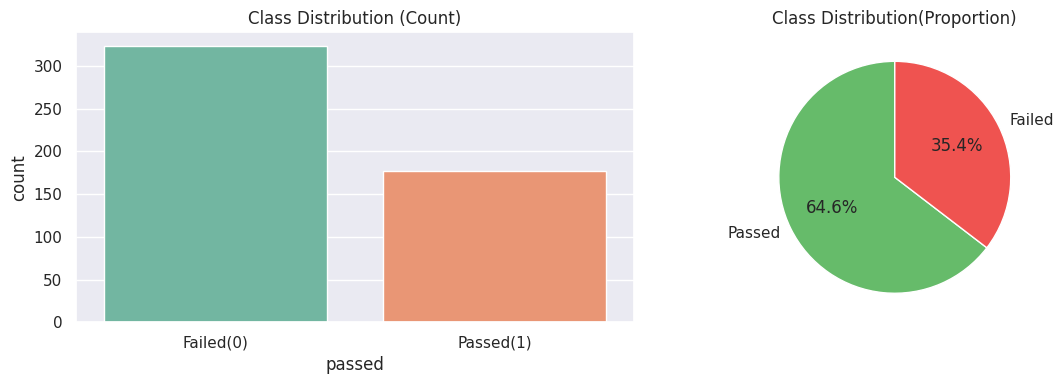

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# countplot
sns.countplot(data=df, x='passed', palette='Set2', ax=axes[0])
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xticklabels(['Failed(0)', 'Passed(1)'])

# Pie chart
df['passed'].value_counts().plot.pie(
    labels=['Passed', 'Failed'],
    autopct = '%1.1f%%',
    colors=['#66bb6a','#ef5350'],
    ax=axes[1],
    startangle=90
)
axes[1].set_title('Class Distribution(Proportion)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

#### Univariate analysis

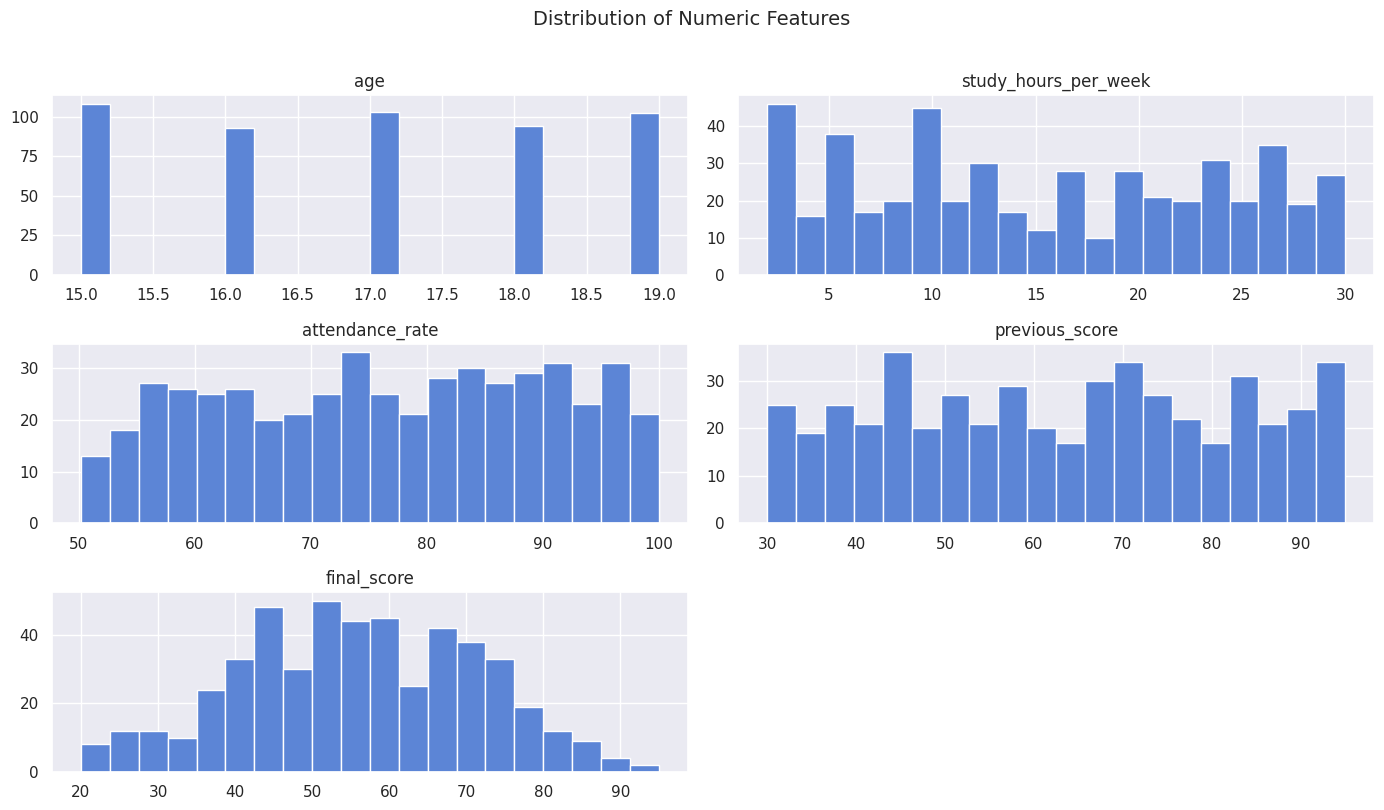

In [ ]:
# select categorical and numerical feature columns (exclude_target)
num_features = ['age', 'study_hours_per_week', 'attendance_rate', 'previous_score', 'final_score']

cat_features = ['gender', 'parent_education', 'internet_access', 'extracurricular']


# Histograms for numeric features
df[num_features].hist(bins=20, figsize=(14,8), color='#5c85d6', edgecolor='white')
plt.suptitle('Distribution of Numeric Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


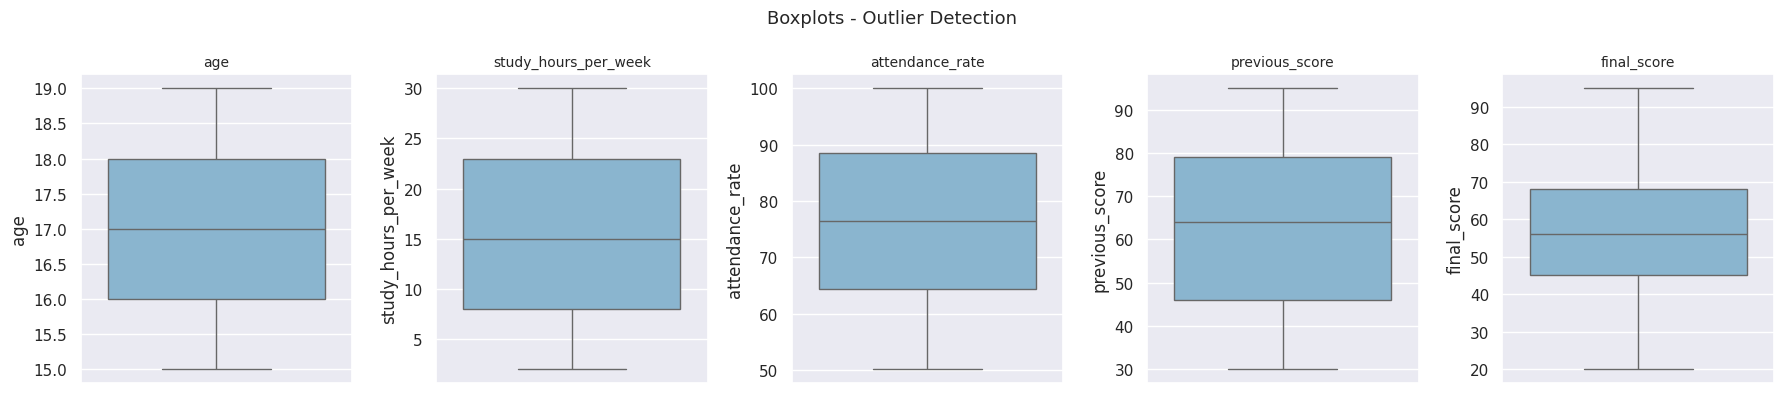

In [141]:
# Boxplots for numeric features(spot outliers)
fig, axes = plt.subplots(1, len(num_features), figsize=(18,4))
for ax, col in zip(axes, num_features):
    sns.boxplot(y=df[col], ax=ax, color='#7eb8da')
    ax.set_title(col, fontsize=10)
plt.suptitle('Boxplots - Outlier Detection', fontsize=13)
plt.tight_layout()
plt.show()

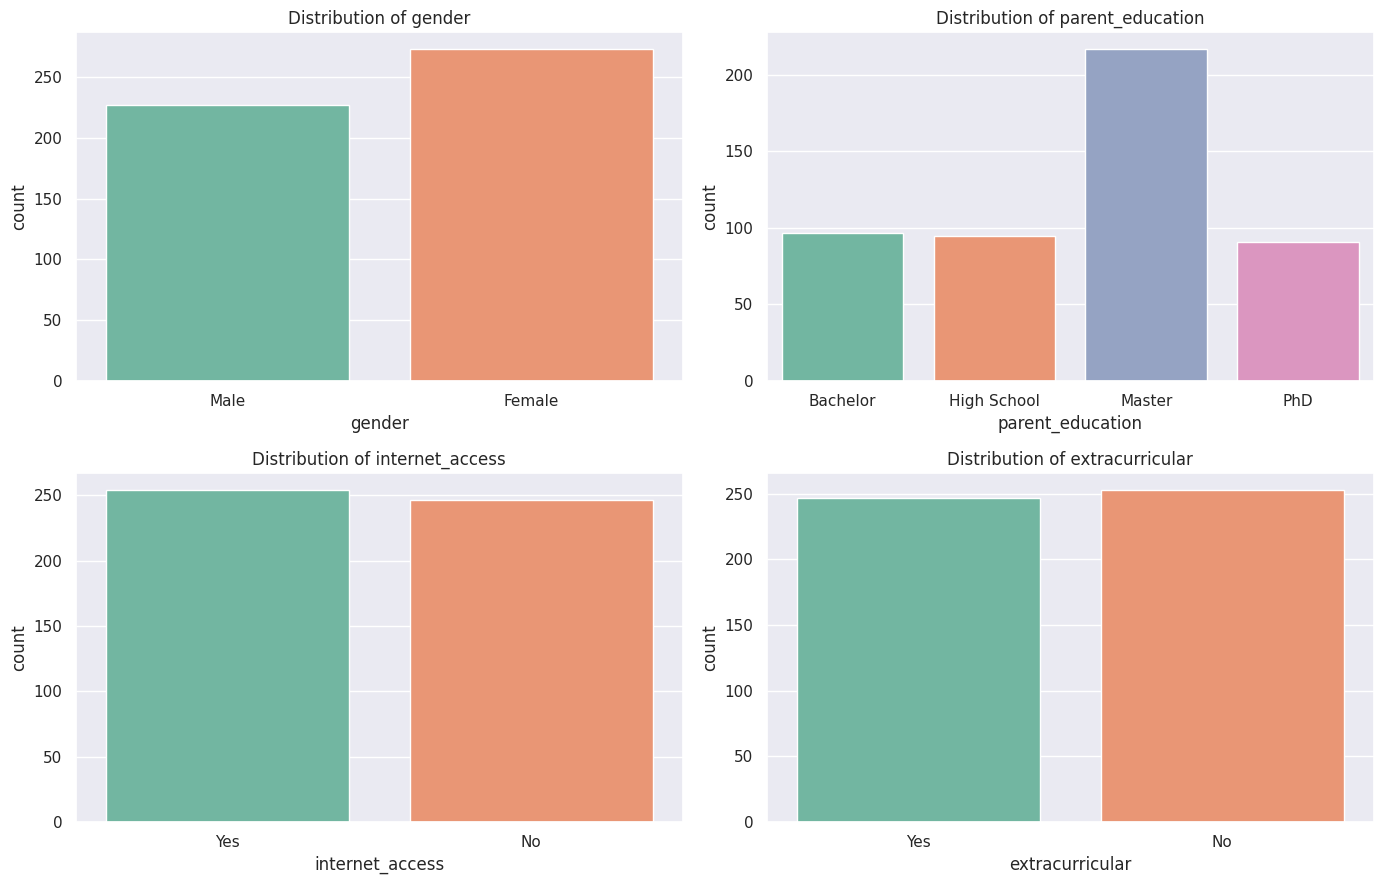

In [144]:
# count plots for categorical features
fig, axes = plt.subplots(2, 2, figsize=(14,9))
axes= axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(data=df, x=col, palette='Set2', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

#### Bivariate Analysis

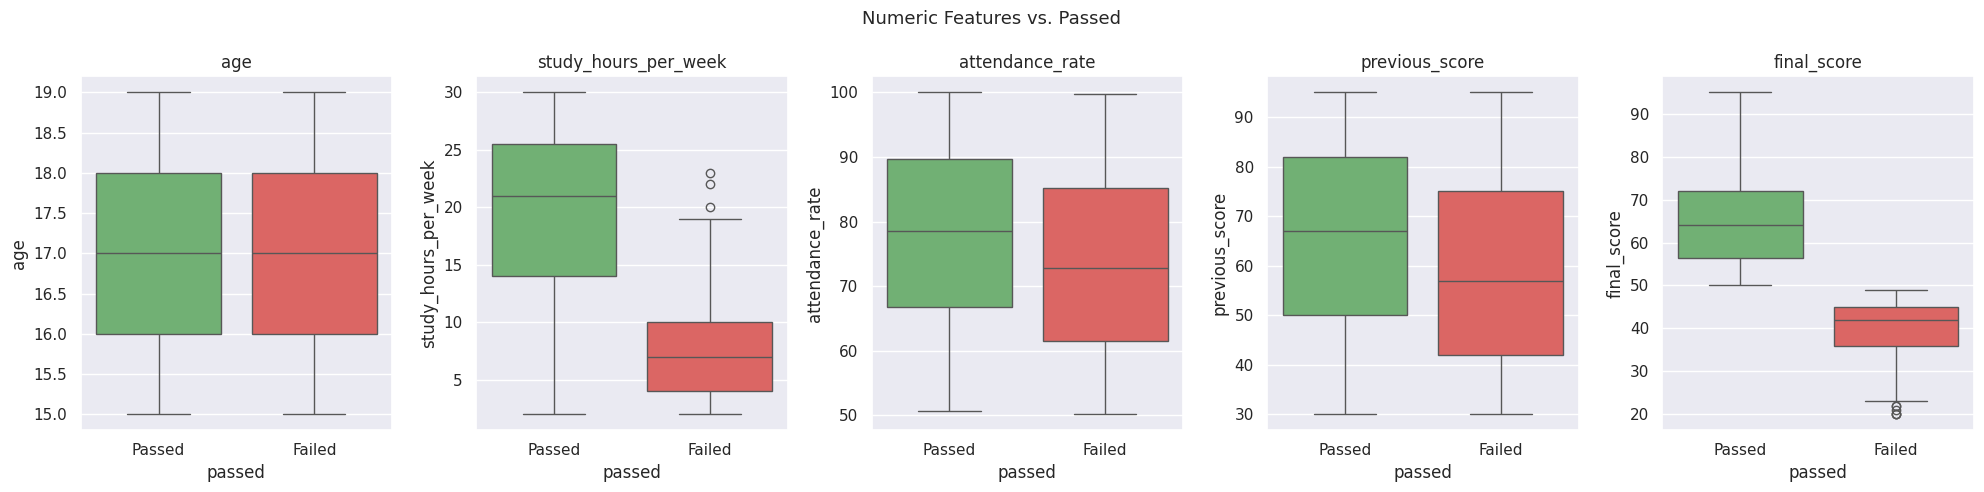

In [152]:
# Numeric feature vs Passed (boxplots)
# A clear separation between the two boxes = strong predictor
fig, axes = plt.subplots(1, len(num_features), figsize=(20,5))

for ax, col in zip(axes, num_features):
    sns.boxplot(data=df, x='passed', y=col,
                palette={'Yes': '#66bb6a', 'No': '#ef5350'}, ax=ax
                )
    ax.set_title(col)
    ax.set_xticklabels(['Passed', 'Failed'])
    
plt.suptitle('Numeric Features vs. Passed', fontsize=13)
plt.tight_layout()
plt.show()

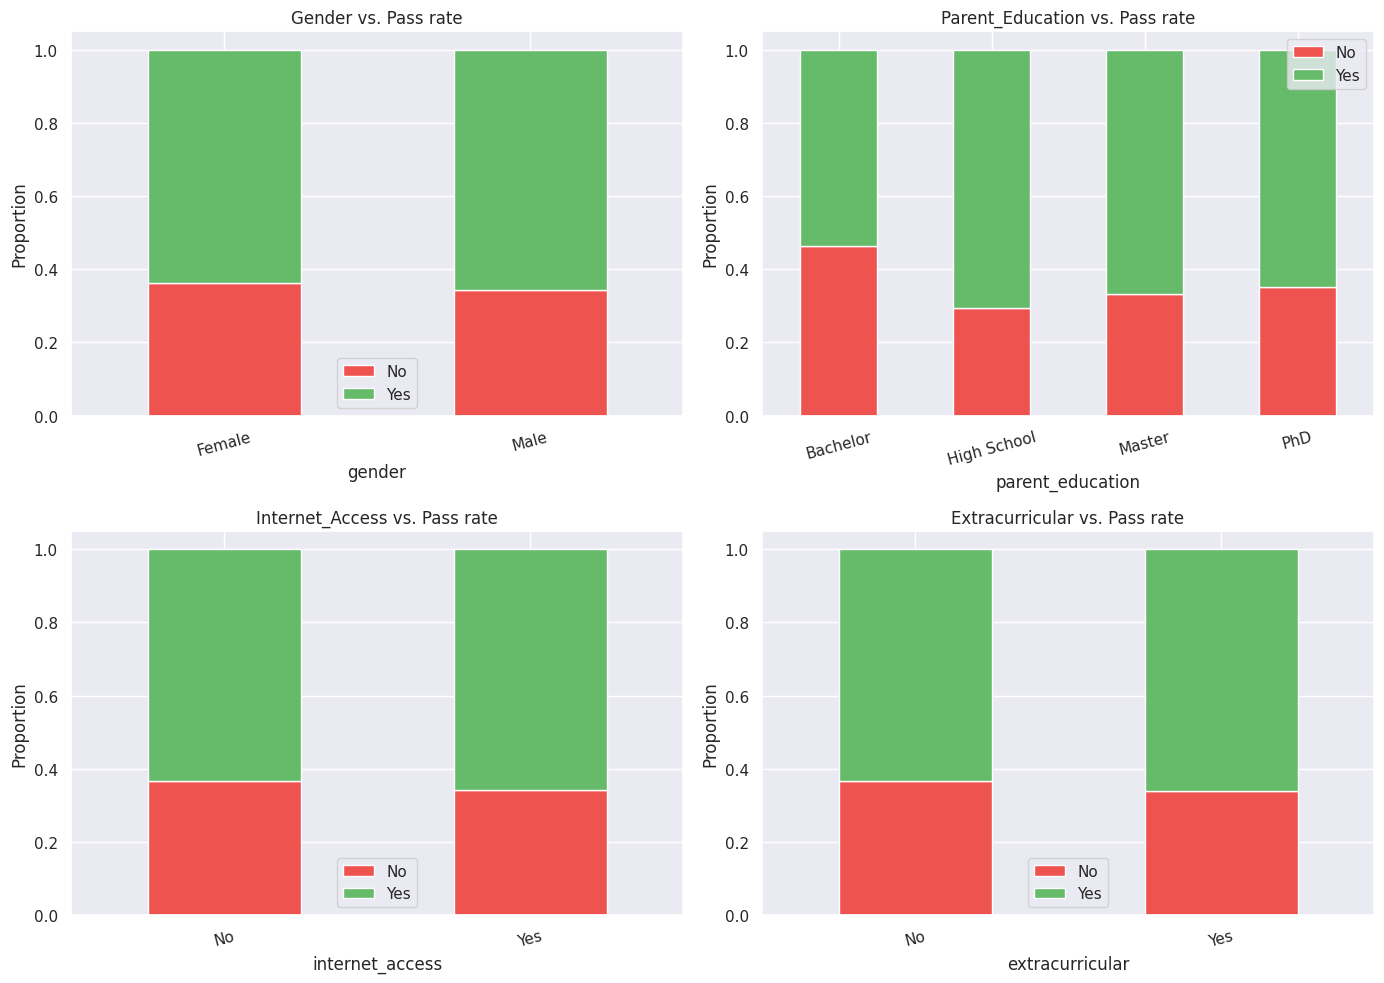

In [160]:
# categorical features  vs passed (stacked bar / crosstab)
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    #crosstab gives us the proportion of pass/fail within each category
    ct = pd.crosstab(df[col], df['passed'], normalize='index')
    ct.plot(
        kind='bar', stacked=True,
        color=['#ef5350', '#66bb6a'],
        ax=axes[i], legend=True, rot=15
    )
    axes[i].set_title(f'{col.title()} vs. Pass rate')
    axes[i].set_ylabel('Proportion')
    axes[i].legend()
    
plt.tight_layout()
plt.show()

In [162]:
# correlation heatmap
plt.figure(figsize=(9,7))
corr_matrix = df[num_features + ['passed']].corr() 
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdY1Gn',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Matrix - Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()

ValueError: could not convert string to float: 'Yes'

<Figure size 900x700 with 0 Axes>